# [Elasticsearch VectorDB](https://www.elastic.co/elasticsearch/)


## 1. Elasticsearch란?
> Elasticsearch는 Apache Lucene 기반의 분산형 RESTful 검색 및 분석 엔진으로, 벡터 검색과 전통적인 키워드 검색을 모두 지원하는 강력한 데이터베이스입니다.


### 주요 특징
- **하이브리드 검색**: 벡터 검색(Semantic)과 키워드 검색(Lexical)을 동시에 지원
- **실시간 검색**: 준실시간(Near Real-Time) 검색 및 분석 기능
- **확장성**: 수평적 확장이 용이한 분산 아키텍처
- **RESTful API**: 직관적인 HTTP REST API 제공
- **강력한 분석 기능**: Kibana를 통한 시각화 및 대시보드
- **다양한 검색 전략**: Dense Vector, Sparse Vector(ELSER), BM25 등 지원


### 사용 사례
- 엔터프라이즈 검색 시스템
- 로그 및 이벤트 데이터 분석
- RAG (Retrieval Augmented Generation) 시스템
- 하이브리드 검색 (의미 검색 + 키워드 검색)
- 실시간 애플리케이션 성능 모니터링
- 전자상거래 상품 검색


## 2. Elasticsearch vs 다른 벡터 데이터베이스


### Elasticsearch의 장점
- **하이브리드 검색**: 벡터 검색과 전통적인 텍스트 검색을 동시에 활용 가능
- **성숙한 생태계**: Elastic Stack (Elasticsearch, Logstash, Kibana, Beats)의 풍부한 도구
- **강력한 분석**: 집계(Aggregation) 기능을 통한 복잡한 데이터 분석
- **검증된 안정성**: 수년간 운영된 엔터프라이즈급 안정성
- **다양한 배포 옵션**: Self-hosted, Elastic Cloud 등
- **실시간 업데이트**: 준실시간 인덱싱 및 검색


### 다른 솔루션과의 비교

| 특성 | Chroma | pgvector | Qdrant | Milvus | Elasticsearch |
|------|--------|----------|--------|--------|---------------|
| **복잡도** | 낮음 | 중간 | 중간 | 높음 | 중간 |
| **설정 난이도** | 매우 쉬움 | 쉬움 | 쉬움 | 어려움 | 중간 |
| **확장성** | 소규모 | 중규모 | 중대규모 | 대규모 | 대규모 |
| **검색 속도** | 보통 | 보통 | 빠름 | 매우 빠름 | 빠름 |
| **하이브리드 검색** | 제한적 | 가능 | 가능 | 가능 | **탁월함** |
| **분석 기능** | 없음 | 기본 | 제한적 | 제한적 | **매우 강력** |
| **생태계** | 신생 | PostgreSQL | 성장 중 | 성장 중 | **매우 성숙** |
| **운영 경험** | 부족 | 풍부 | 중간 | 중간 | **매우 풍부** |
| **메모리 효율** | 보통 | 좋음 | 좋음 | 매우 좋음 | 좋음 |
| **기존 데이터 통합** | 어려움 | **쉬움** | 중간 | 중간 | **쉬움** |

#### 선택 가이드
- **Chroma**: 빠른 프로토타이핑, 소규모 프로젝트
- **pgvector**: 기존 PostgreSQL 인프라 활용, 중간 규모
- **Qdrant**: 고성능 벡터 검색, 풍부한 필터링
- **Milvus**: 초대규모 벡터 데이터, 최고 성능 요구
- **Elasticsearch**: 하이브리드 검색, 복잡한 분석, 엔터프라이즈 환경, 기존 Elastic Stack 활용


### Elasticsearch 용어 

| RDB 개념          | Elasticsearch 대응 개념                                           | 설명                                                                          |
| --------------- | ------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **Database**    | **Index**                                                     | 데이터가 저장되는 최상위 논리 단위. RDB의 Database와 가장 유사.                                  |
| **Table**       | **(Type)** → *Deprecated*<br>**→ 사실상 Index 하나가 하나의 Table 역할** | 과거에는 하나의 Index 안에 여러 Type이 존재했지만, Type은 폐지됨. 현재는 **Index = Table** 개념으로 사용. |
| **Column**      | **Field**                                                     | 문서(document)의 속성. RDB의 컬럼과 동일한 역할. 각 필드는 타입(text, keyword, integer 등)을 가짐.  |
| **Row**         | **Document**                                                  | 인덱스에 저장되는 실제 데이터. JSON 객체 형태.                                               |
| **Primary Key** | **_id**                                                       | 문서를 식별하는 고유 ID. 명시하지 않으면 ES가 자동 생성.                                         |


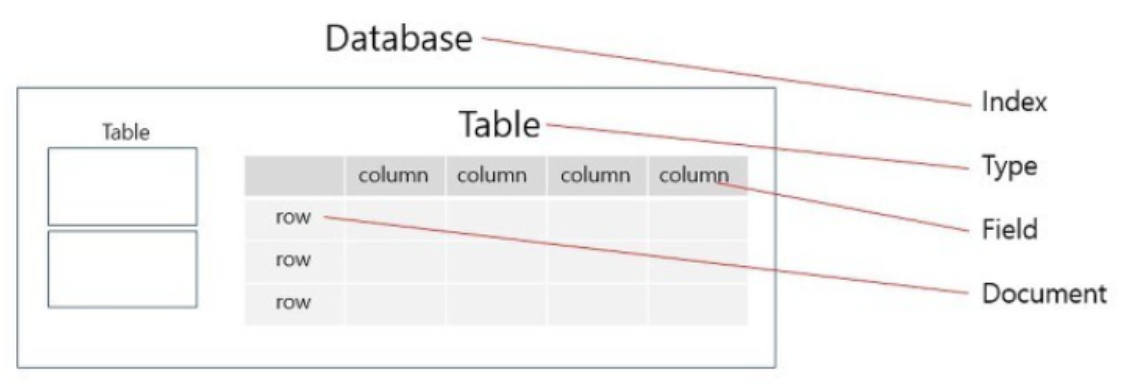

## 3. 설치 및 설정

Elasticsearch를 Docker Compose를 사용하여 설치하겠습니다.


### 3.1 Docker Compose로 Elasticsearch 실행

`elasticsearch/docker-compose.yml` 파일을 사용하여 Elasticsearch와 Kibana를 실행합니다.

```bash
cd elasticsearch
docker-compose up -d
```


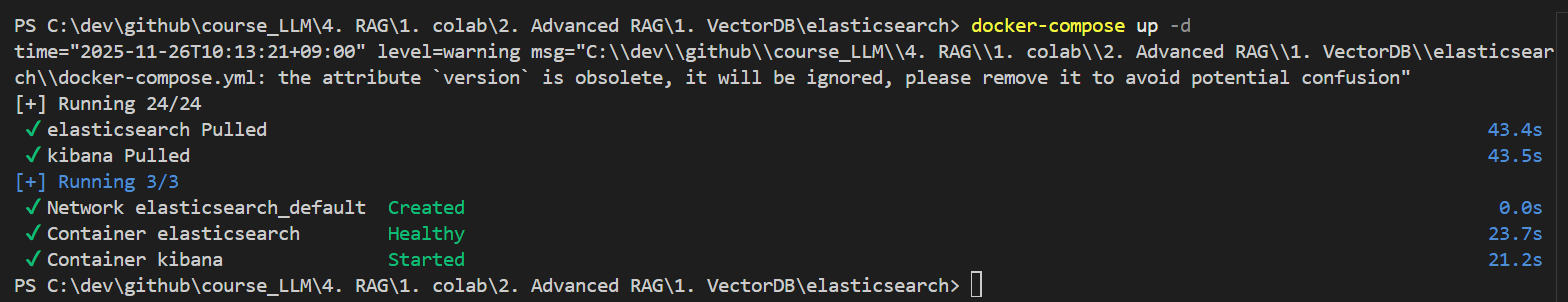

### 3.2 Elasticsearch 연결 확인
- Elasticsearch REST API: http://localhost:9200

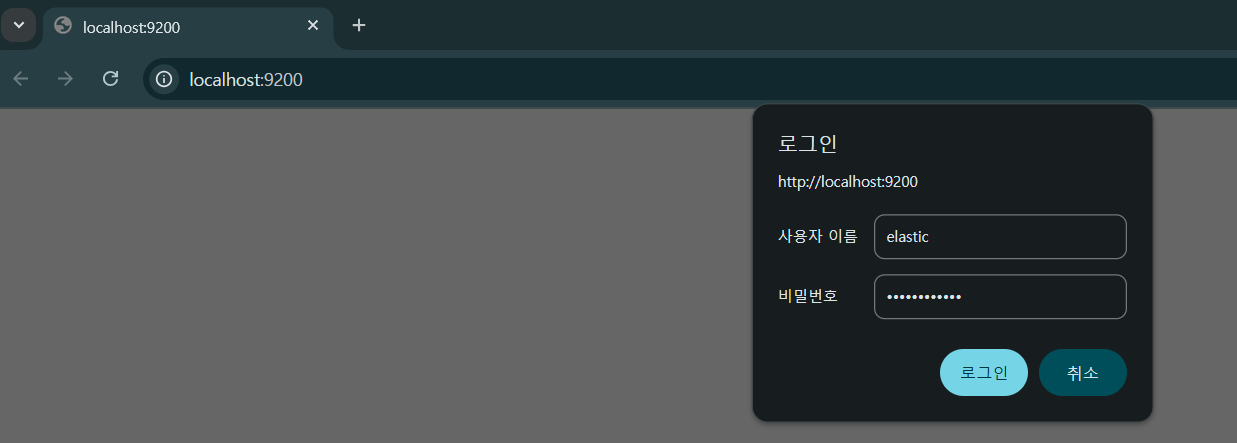

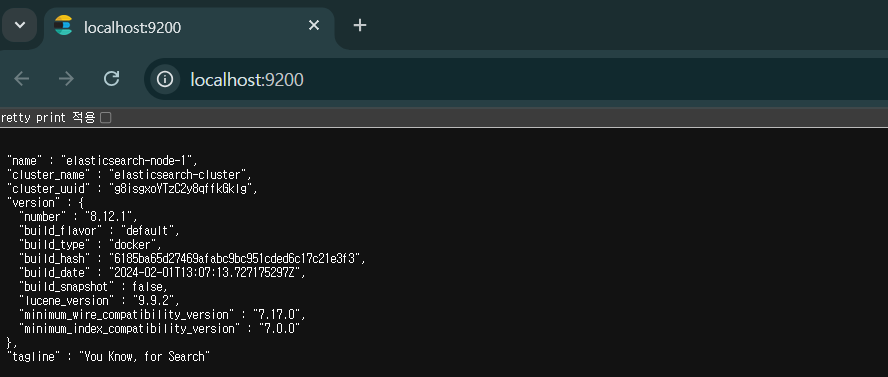

In [1]:
from elasticsearch import Elasticsearch
import warnings

# SSL 경고 무시 (개발 환경용)
warnings.filterwarnings('ignore')

# Elasticsearch 클라이언트 생성
# elasticsearch 9.x는 명시적인 scheme 지정이 필요합니다
try:
    es_client = Elasticsearch(
        ["http://localhost:9200"],  # 리스트 형태로, scheme 포함
        basic_auth=("elastic", "changeme123!"),  # 인증 정보 (보안 활성화 시 필수)
        verify_certs=False,
        ssl_show_warn=False,
        request_timeout=30,
        max_retries=3,
        retry_on_timeout=True,
        # 호환성 헤더 비활성화 (개발 환경용)
        headers={"accept": "application/json", "content-type": "application/json"}
    )
    
    # 연결 확인
    if es_client.ping():
        print("Elasticsearch 연결 성공!")
        print()
        
        # 클러스터 정보
        info = es_client.info()
        print(f"버전: {info['version']['number']}")
        print(f"클러스터 이름: {info['cluster_name']}")
        print(f"노드 이름: {info['name']}")
        print()
        print(f"Elasticsearch URL: http://localhost:9200")
    else:
        print("Elasticsearch 연결 실패 (ping 실패)")
        
except Exception as e:
    print("Elasticsearch 연결 중 오류 발생:")
    print(f"   에러 타입: {type(e).__name__}")
    print(f"   에러 메시지: {str(e)}")

Elasticsearch 연결 성공!

버전: 8.12.1
클러스터 이름: elasticsearch-cluster
노드 이름: elasticsearch-node-1

Elasticsearch URL: http://localhost:9200


### 3.3 Kibana Web UI
> Kibana를 통해 Elasticsearch를 시각적으로 관리할 수 있습니다.

로그인 정보:
- 로그인 페이지: http://localhost:5601
- Username: elastic
- Password: changeme123!

주요 기능:
- Dev Tools: Elasticsearch API를 직접 테스트
- Discover: 데이터 탐색 및 검색
- Dashboard: 데이터 시각화
- Index Management: 인덱스 관리

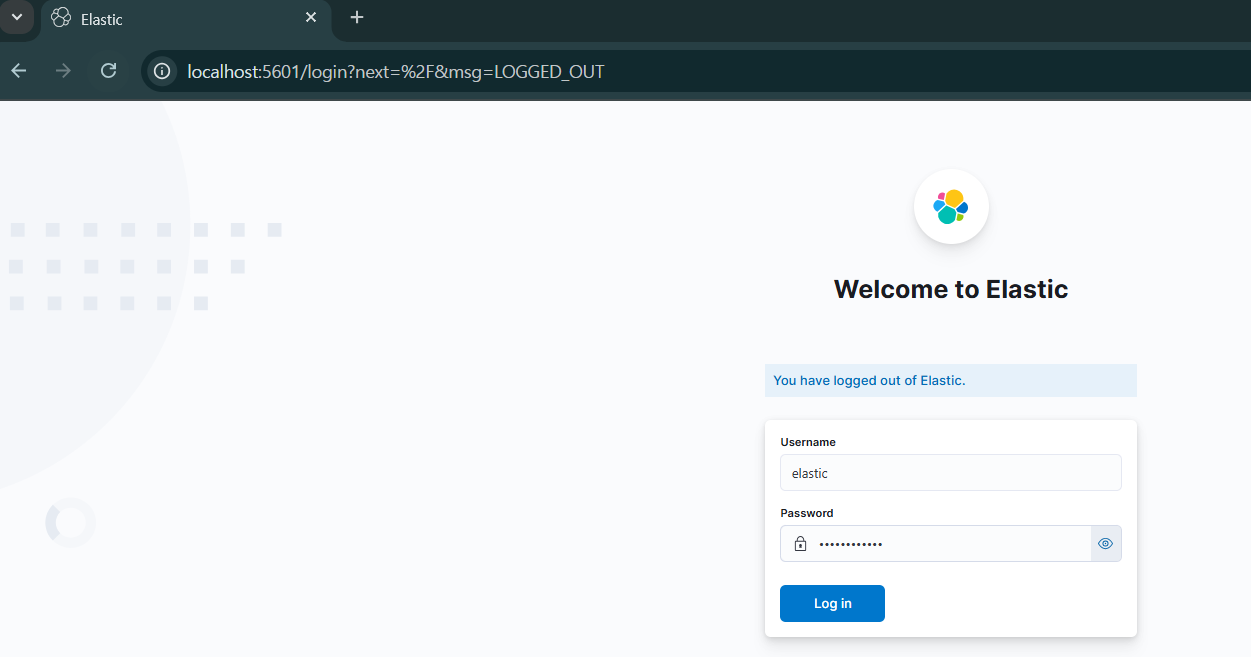

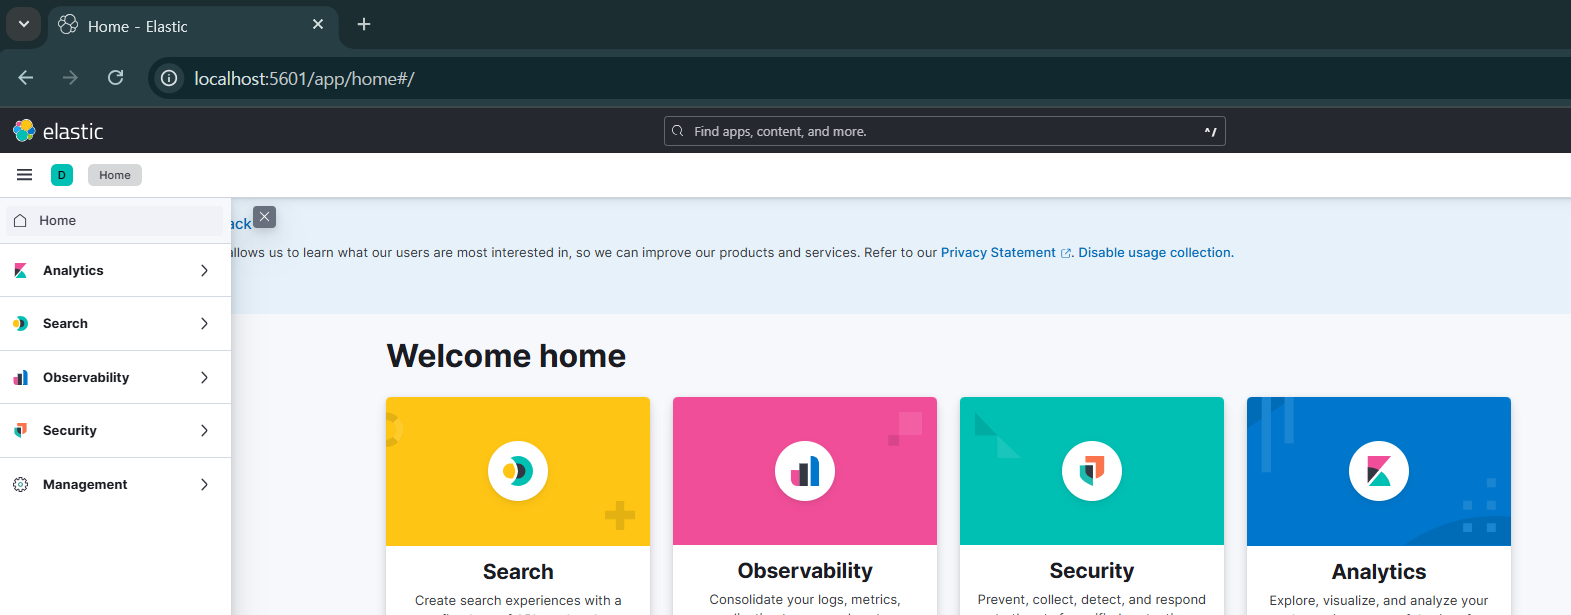

## 4. Elasticsearch를 이용한 벡터 데이터 저장


### 4.1 데이터 확인 

In [2]:
import pandas as pd 

file_path = "./data/naver_news_detail_20251128.csv"
df = pd.read_csv(file_path)

print(f"(전체 데이터의 수, 전체 컬럼 수): {df.shape}")

(전체 데이터의 수, 전체 컬럼 수): (20, 12)


In [3]:

# 데이터 확인
print(f"전체 데이터: {len(df)}개")
df[['카테고리', '언론사', '기자명', '발행일자', '뉴스_제목', '링크', '뉴스_내용']].head(2)


전체 데이터: 20개


,카테고리,언론사,기자명,발행일자,뉴스_제목,링크,뉴스_내용
0,경제,국민일보,이광수 기자,2025-11-27 18:51:11,업비트 ‘445억 해킹 사고’ 인지 → 공지 7시간 51분 ‘늑장’,https://n.news.naver.com/mnews/article/005/000...,‘네이버와 합병행사 의식했나’ 의혹 피해 규모 ‘오락가락’ 투자자들 불안 6년 전과...
1,경제,SBS,장훈경 기자,2025-11-28 15:44:57,"국민연금, 9월 말 수익률 11.31%…올해 138조 7천억 원 수익",https://n.news.naver.com/mnews/article/055/000...,▲ 국민연금공단 서울북부지역 본부 국민연금공단 기금운용본부는 올해 9월 말까지 기금...


### 4.2 데이터 로드


In [ ]:
from langchain_community.document_loaders import CSVLoader

loader = CSVLoader(
    file_path=file_path,          # 불러올 CSV 파일 경로 (변수 file_path)
    encoding='utf-8',             # CSV 파일 인코딩 방식

    # Document의 본문(content)으로 사용할 컬럼 지정
    # 아래 컬럼 값들이 하나의 문자열로 합쳐져 page_content가 됨
    content_columns=['뉴스_제목', '뉴스_내용'],

    # Document의 source 정보로 사용할 컬럼 (예: 날짜)
    source_column='링크',

    # metadata로 포함할 컬럼들 (검색/필터 용도로 활용 가능)
    metadata_columns=['카테고리', '언론사', '기자명', '발행일자'],

    # CSV 파싱 설정
    csv_args={
        'delimiter': ',',         # CSV의 열 구분자 (기본 콤마)
    }
)

In [5]:
documents = loader.load()
print(f"파일 로드 완료: {len(documents)}개 문서")


파일 로드 완료: 20개 문서


In [6]:
documents[0].metadata

{'source': 'https://n.news.naver.com/mnews/article/005/0001817155',
 'row': 0,
 '카테고리': '경제',
 '언론사': '국민일보',
 '기자명': '이광수 기자',
 '발행일자': '2025-11-27 18:51:11'}

In [7]:
print(documents[0].page_content)

뉴스_제목: 업비트 ‘445억 해킹 사고’ 인지 → 공지 7시간 51분 ‘늑장’
뉴스_내용: ‘네이버와 합병행사 의식했나’ 의혹 피해 규모 ‘오락가락’ 투자자들 불안 6년 전과 같은 날 해킹 탈취 반복 국내 가상자산(암호화폐) 거래소 1위 업체 업비트에서 약 445억원 규모의 해킹 사고가 발생했다. 업비트는 피해 인지 후 7시간51분 만에 이 사실을 공개했는데, 운영사인 두나무와 네이버파이낸셜의 합병 행사를 의식한 것 아니냐는 의혹이 제기된다. 27일 두나무에 따르면 이날 오전 4시42분 업비트에서 약 445억원 규모의 가상화폐가 알 수 없는 외부 지갑으로 전송된 정황이 포착됐다. 대상 자산은 솔라나 네트워크 계열 자산인 솔라나(SOL)와 더블제로(2Z), 액세스프로토콜(ACS) 등 24종이다. 업비트는 해킹 사고 인지 직후 금융감독원과 한국인터넷진흥원(KISA)에 피해 사실을 보고했다. 해킹 인지 45분 뒤인 5시27분에 솔라나 네트워크 계열 디지털자산 입출금을 중단했다. 8시55분에는 모든 디지털자산 입출금을 중단했다. 다만 이 과정에서 중단 이유는 밝히지 않았다. 해킹


### 4.3 임베딩 모델 설정


In [10]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")


In [12]:
# 임베딩 차원 (모델에 따라 조정)
embeddings_dims = len(embeddings.embed_query("안녕하세요?"))

embeddings_dims

1024

### 4.4 벡터 인덱스 생성


In [13]:
# 인덱스 이름
index_name = "naver_news"

# 기존 인덱스 삭제 (있다면)
if es_client.indices.exists(index=index_name):
    es_client.indices.delete(index=index_name)
    print(f"기존 인덱스 '{index_name}' 삭제")

# 벡터 인덱스 매핑 생성 (qwen3-embedding:0.6b는 1024차원)
index_mapping = {
    "mappings": {
        "properties": {
            "text": {
                "type": "text",
                "analyzer": "standard"
            },
            "embedding": {
                "type": "dense_vector",
                "dims": embeddings_dims,  # 임베딩 차원 (모델에 따라 조정)
                "index": True,
                "similarity": "cosine"  # 코사인 유사도
            },
            "metadata": {
                "type": "object",
                "enabled": True
            }
        }
    }
}

# 인덱스 생성
es_client.indices.create(index=index_name, body=index_mapping)
print(f"인덱스 '{index_name}' 생성 완료")


인덱스 'naver_news' 생성 완료


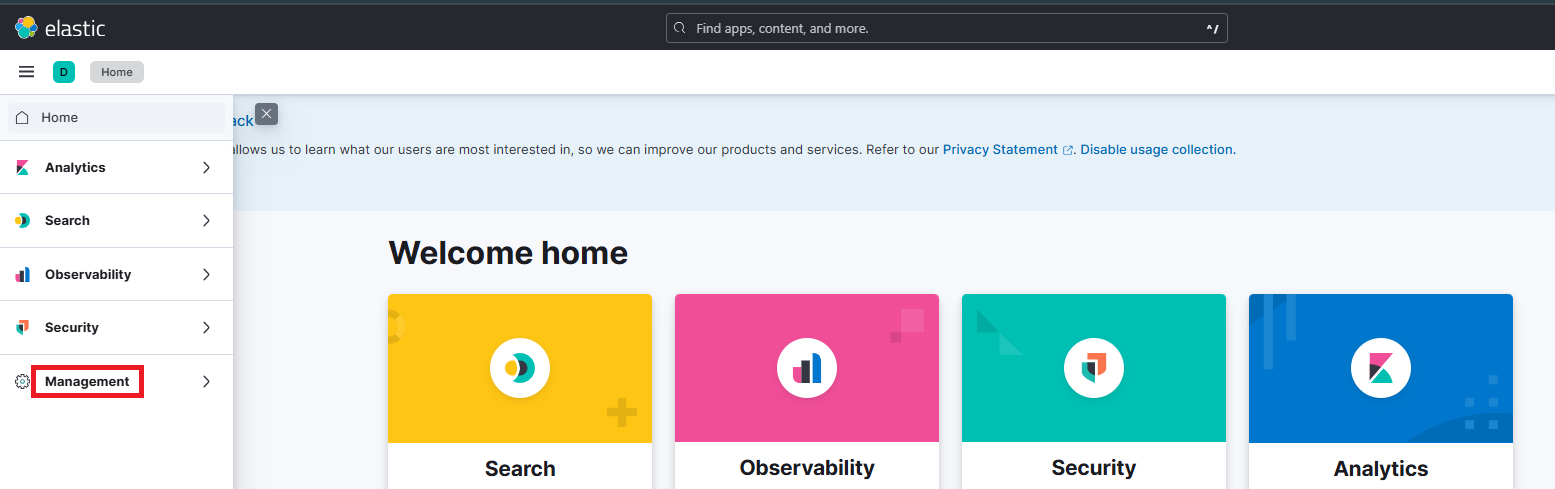

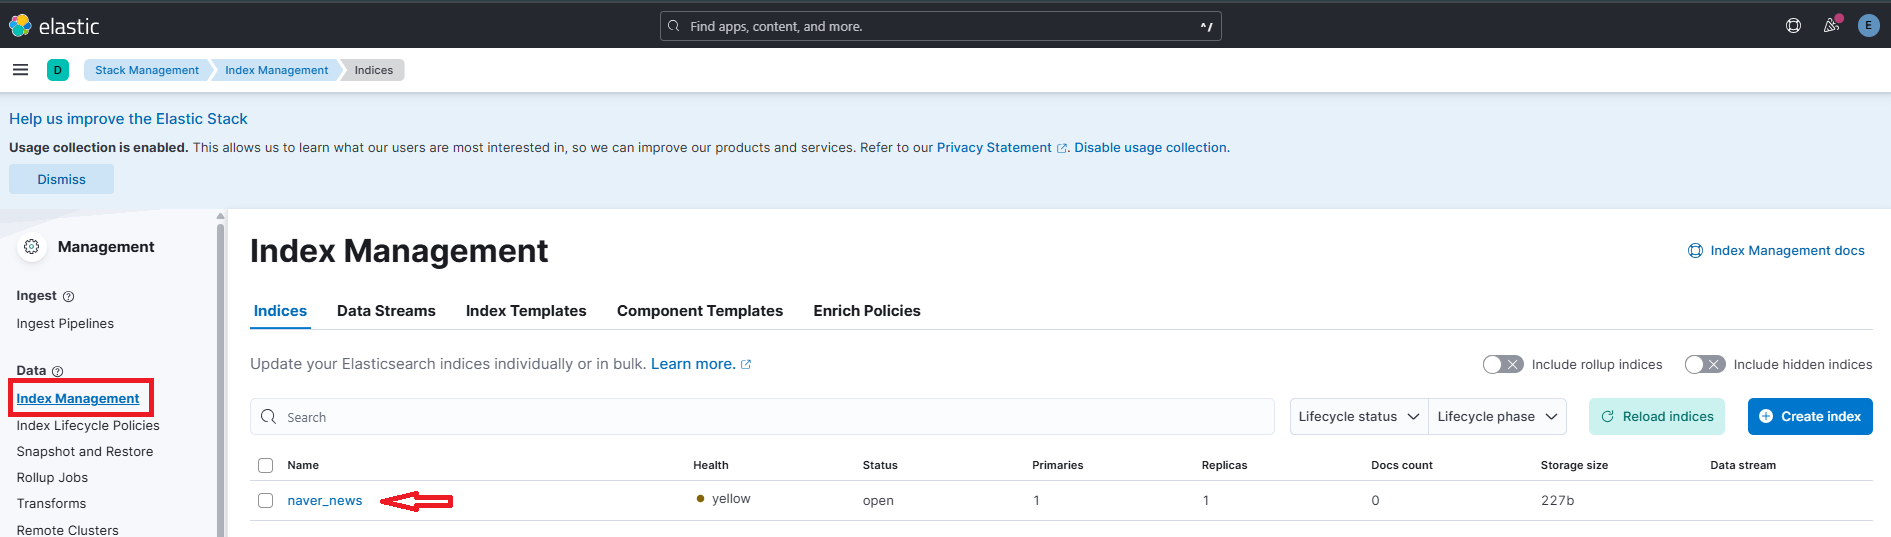

### 4.5 문서 임베딩 및 인덱싱


In [14]:
from elasticsearch.helpers import bulk

# 문서 임베딩 생성
texts = [doc.page_content for doc in documents]
embeddings_list = embeddings.embed_documents(texts)

print(f"임베딩 생성 완료: {len(embeddings_list)}개")
print(f"임베딩 차원: {len(embeddings_list[0])}")

# Elasticsearch에 벌크 인덱싱
def generate_docs():
    for i, (doc, embedding) in enumerate(zip(documents, embeddings_list)):
        yield {
            "_index": index_name,
            "_id": i,
            "_source": {
                "text": doc.page_content,
                "embedding": embedding,
                "metadata": doc.metadata
            }
        }

# 벌크 인덱싱 실행
success, failed = bulk(es_client, generate_docs())
print(f"인덱싱 완료: {success}개 성공")

# 인덱스 새로고침 (검색 가능하도록)
es_client.indices.refresh(index=index_name)

# 저장된 문서 수 확인
count = es_client.count(index=index_name)['count']
print(f"저장된 문서 수: {count}개")


임베딩 생성 완료: 20개
임베딩 차원: 1024
인덱싱 완료: 20개 성공
저장된 문서 수: 20개


> Docs count를 통해 데이터가 20개 저장된 것을 확인할 수 있음 

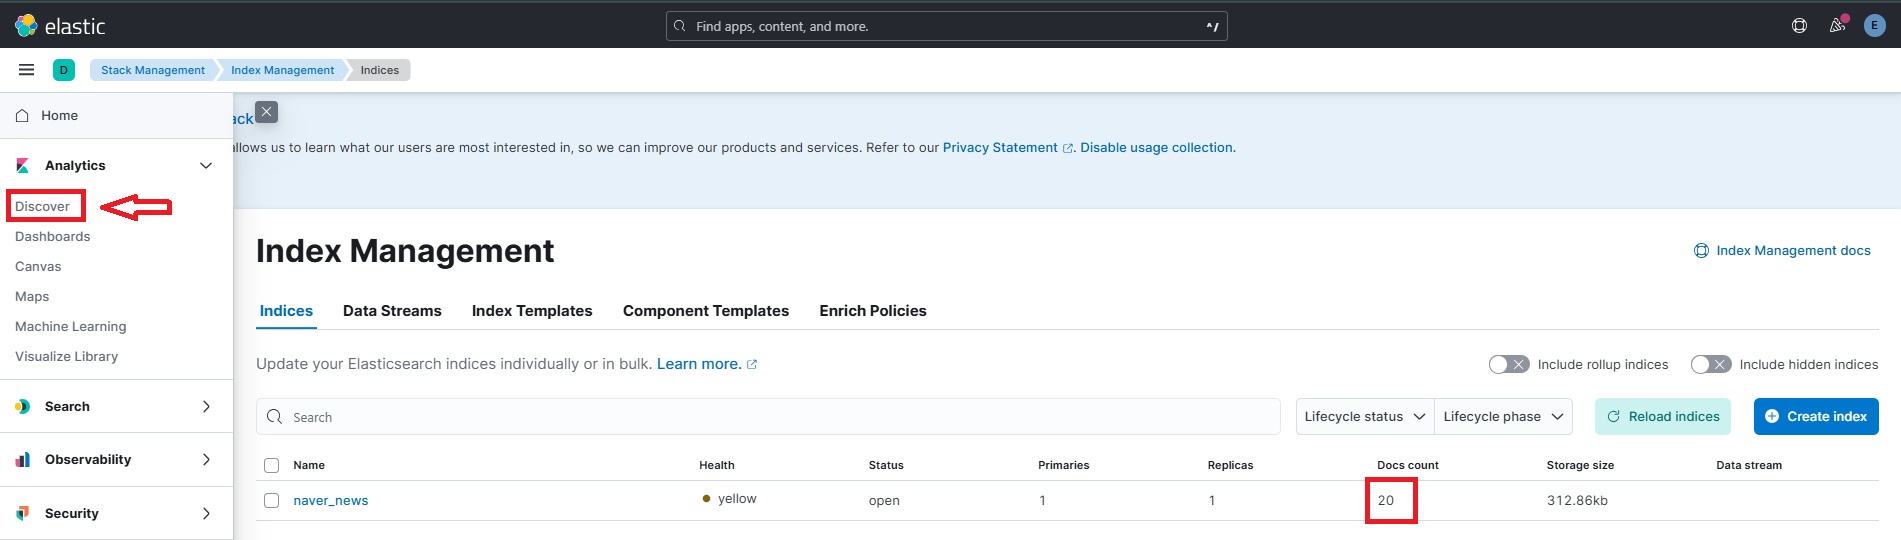

> Discover를 이용해서 데이터 확인하기 

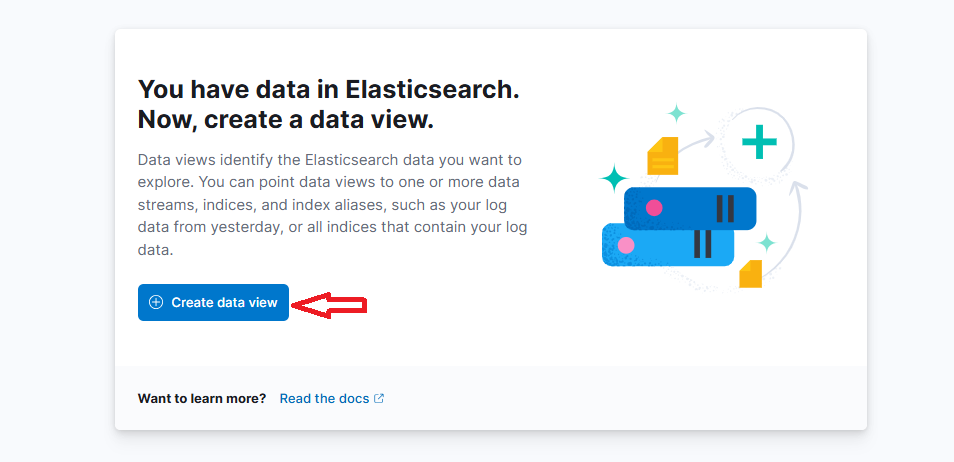

> index pattern의 데이터는 `인덱스 이름` + `*` 와 같이 응용해서 생성 

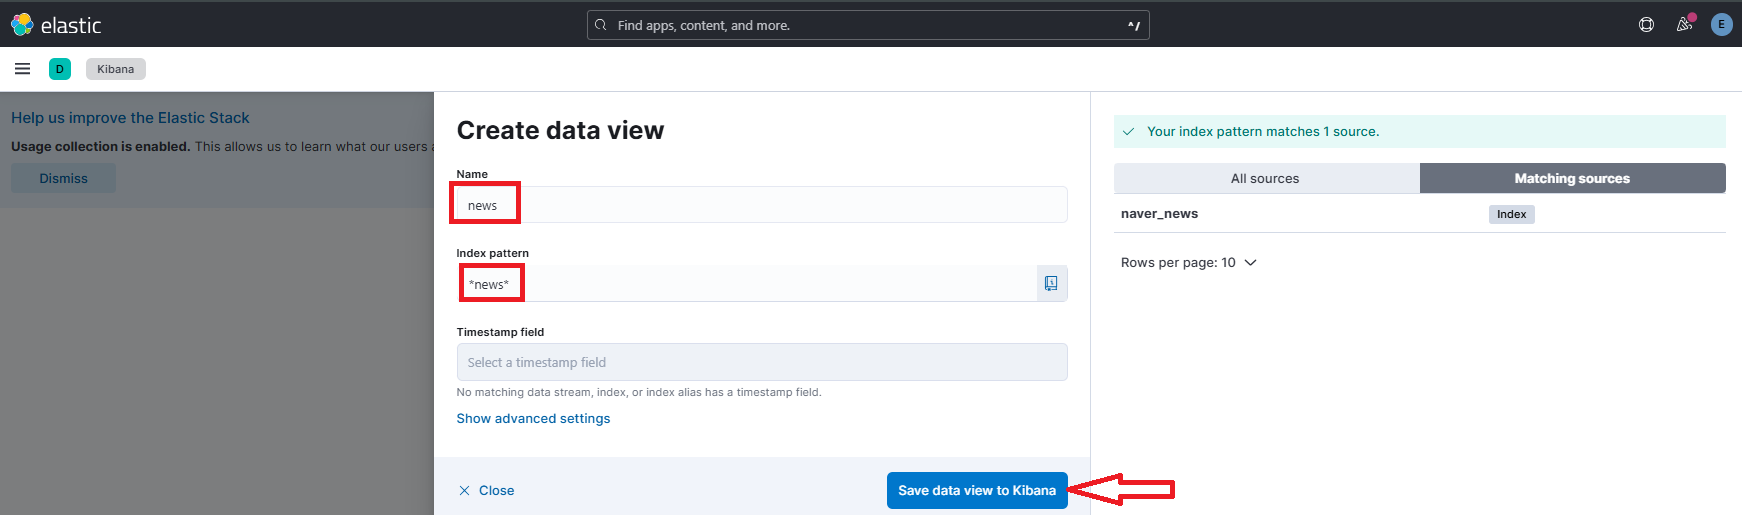

> 데이터 조회 예시 

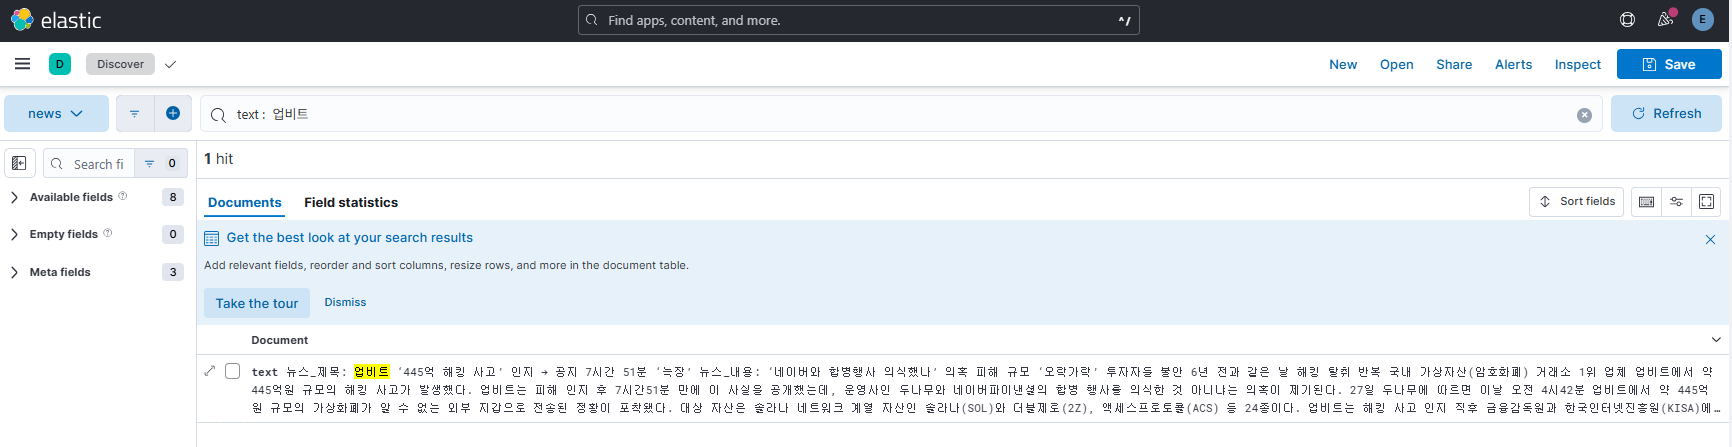

## 5. Elasticsearch를 이용한 벡터 검색 
elasticsearch 모듈을 직접 사용하여 벡터 검색을 구현합니다.

### 5.1 BM25 키워드 검색 (벡터 검색 없이)

In [15]:
def keyword_search(query_text, k=3, index_name="naver_news"):
    """
    BM25 키워드 검색 (벡터 검색 없이)
    
    Args:
        query_text: 검색할 쿼리 텍스트
        k: 반환할 결과 개수
        index_name: 검색할 인덱스 이름
    
    Returns:
        검색 결과 리스트
    """
    # BM25 검색 쿼리
    search_query = {
        "query": {
            "match": {
                "text": query_text
            }
        },
        "size": k,
        "_source": ["text", "metadata"]
    }
    
    # 검색 실행
    response = es_client.search(index=index_name, body=search_query)
    
    # 결과 파싱
    results = []
    for hit in response['hits']['hits']:
        results.append({
            'text': hit['_source']['text'],
            'metadata': hit['_source'].get('metadata', {}),
            'score': hit['_score']
        })
    
    return results


In [16]:
# BM25 검색 테스트
query = "네이버"
results = keyword_search(query, k=3)

print(f"BM25 키워드 검색: {query}\n")
print("검색 결과:")
print("=" * 80)
for i, result in enumerate(results, 1):
    print(f"{i}. [BM25 점수: {result['score']:.4f}] {result['text'][:100]}...")
    print()

BM25 키워드 검색: 네이버

검색 결과:
1. [BM25 점수: 4.5457] 뉴스_제목: 네이버, 서울대병원과 의료 특화 LLM 공개...“의료 소버린 AI 실현”
뉴스_내용: 한국 의료법·진료 가이드라인 학습한 모델 의사국가고시 96.4점...의료진 업무...



### 5.2 벡터 유사도 검색


In [17]:
def similarity_search(query_text, k=3, index_name="naver_news"):
    """
    벡터 유사도 검색 함수
    
    Args:
        query_text: 검색할 쿼리 텍스트
        k: 반환할 결과 개수
        index_name: 검색할 인덱스 이름
    
    Returns:
        검색 결과 리스트
    """
    # 쿼리 텍스트를 임베딩으로 변환
    query_embedding = embeddings.embed_query(query_text)
    
    # KNN 검색 쿼리
    search_query = {
        "knn": {
            "field": "embedding",
            "query_vector": query_embedding,
            "k": k,
            "num_candidates": 100  # 후보 문서 수
        },
        "_source": ["text", "metadata"]  # 반환할 필드
    }
    
    # 검색 실행
    response = es_client.search(index=index_name, body=search_query)
    
    # 결과 파싱
    results = []
    for hit in response['hits']['hits']:
        results.append({
            'text': hit['_source']['text'],
            'metadata': hit['_source'].get('metadata', {}),
            'score': hit['_score']
        })
    
    return results


In [18]:
# 검색 테스트
query = "업비트 해킹 사고 뉴스는?"
results = similarity_search(query, k=3)

print(f"검색 쿼리: {query}\n")
print("검색 결과:")
print("=" * 80)
for i, result in enumerate(results, 1):
    print(f"{i}. {result['text']}")
    print(f"   유사도 점수: {result['score']:.4f}")
    print(f"   메타데이터: {result['metadata']}")
    print()


검색 쿼리: 업비트 해킹 사고 뉴스는?

검색 결과:
1. 뉴스_제목: 업비트 ‘445억 해킹 사고’ 인지 → 공지 7시간 51분 ‘늑장’
뉴스_내용: ‘네이버와 합병행사 의식했나’ 의혹 피해 규모 ‘오락가락’ 투자자들 불안 6년 전과 같은 날 해킹 탈취 반복 국내 가상자산(암호화폐) 거래소 1위 업체 업비트에서 약 445억원 규모의 해킹 사고가 발생했다. 업비트는 피해 인지 후 7시간51분 만에 이 사실을 공개했는데, 운영사인 두나무와 네이버파이낸셜의 합병 행사를 의식한 것 아니냐는 의혹이 제기된다. 27일 두나무에 따르면 이날 오전 4시42분 업비트에서 약 445억원 규모의 가상화폐가 알 수 없는 외부 지갑으로 전송된 정황이 포착됐다. 대상 자산은 솔라나 네트워크 계열 자산인 솔라나(SOL)와 더블제로(2Z), 액세스프로토콜(ACS) 등 24종이다. 업비트는 해킹 사고 인지 직후 금융감독원과 한국인터넷진흥원(KISA)에 피해 사실을 보고했다. 해킹 인지 45분 뒤인 5시27분에 솔라나 네트워크 계열 디지털자산 입출금을 중단했다. 8시55분에는 모든 디지털자산 입출금을 중단했다. 다만 이 과정에서 중단 이유는 밝히지 않았다. 해킹
   유사도 점수: 0.8243
   메타데이터: {'source': 'https://n.news.naver.com/mnews/article/005/0001817155', 'row': 0, '카테고리': '경제', '언론사': '국민일보', '기자명': '이광수 기자', '발행일자': '2025-11-27 18:51:11'}

2. 뉴스_제목: PC 게임 포털도 뚫렸다…611만명 정보 유출
뉴스_내용: 넷마블 PC 게임 포털사이트에서 총 611만명분에 달하는 고객 및 임직원 정보가 해킹으로 유출된 것으로 나타났다. 넷마블은 27일 정보유출 건에 대한 자체 조사 결과를 공개했다. 넷마블에 따르면 현재까지 바둑·장기 등 PC 게임 포털 사이트에서 유출된 회원 정보는 휴면계정을 포함해 총 611만명으로 집계됐다. 유출된 정보는 이름과 생

### 5.3 하이브리드 검색 (벡터 + 키워드)

벡터 검색과 BM25 키워드 검색을 결합한 하이브리드 검색입니다.


In [19]:
def hybrid_search(query_text, k=3, index_name="naver_news"):
    """
    하이브리드 검색: 벡터 검색 + BM25 키워드 검색
    
    Args:
        query_text: 검색할 쿼리 텍스트
        k: 반환할 결과 개수
        index_name: 검색할 인덱스 이름
    
    Returns:
        검색 결과 리스트
    """
    # 쿼리 임베딩
    query_embedding = embeddings.embed_query(query_text)
    
    # 하이브리드 검색 쿼리
    search_query = {
        "query": {
            "bool": {
                "should": [
                    # BM25 키워드 검색
                    {
                        "match": {
                            "text": {
                                "query": query_text,
                                "boost": 1.0  # 키워드 가중치
                            }
                        }
                    }
                ]
            }
        },
        "knn": {
            "field": "embedding",
            "query_vector": query_embedding,
            "k": k,
            "num_candidates": 100,
            "boost": 2.0  # 벡터 검색 가중치 (벡터에 더 높은 가중치)
        },
        "size": k,
        "_source": ["text", "metadata"]
    }
    
    # 검색 실행
    response = es_client.search(index=index_name, body=search_query)
    
    # 결과 파싱
    results = []
    for hit in response['hits']['hits']:
        results.append({
            'text': hit['_source']['text'],
            'metadata': hit['_source'].get('metadata', {}),
            'score': hit['_score']
        })
    
    return results


In [20]:
# 하이브리드 검색 테스트
query = "해킹 사고 뉴스들 조회해줘."
results = hybrid_search(query, k=3)

print(f"하이브리드 검색: {query}\n")
print("검색 결과 (벡터 + 키워드 결합):")
print("=" * 80)
for i, result in enumerate(results, 1):
    print(f"{i}. [점수: {result['score']:.4f}] {result['text'][:100]}...")
    print()


하이브리드 검색: 해킹 사고 뉴스들 조회해줘.

검색 결과 (벡터 + 키워드 결합):
1. [점수: 9.2718] 뉴스_제목: 업비트 ‘445억 해킹 사고’ 인지 → 공지 7시간 51분 ‘늑장’
뉴스_내용: ‘네이버와 합병행사 의식했나’ 의혹 피해 규모 ‘오락가락’ 투자자들 불안 6년 전과 같...

2. [점수: 4.8327] 뉴스_제목: 지난 자율주행차 사고 47건…교통안전공단 통계 최초 공개
뉴스_내용: 주행속도 시속 30㎞ 이하 저속 구간서 주로 발생 내년엔 '차량거동' 정보까지 확대 공개 자율주행...

3. [점수: 1.4785] 뉴스_제목: PC 게임 포털도 뚫렸다…611만명 정보 유출
뉴스_내용: 넷마블 PC 게임 포털사이트에서 총 611만명분에 달하는 고객 및 임직원 정보가 해킹으로 유출된 것으로 나타...



## 6 Elasticsearch Store 구현


In [21]:
from langchain_core.vectorstores.base import VectorStore

class Singleton(type(VectorStore)):
	_instances = {}

	def __call__(cls, *args, **kwargs):
		if cls not in cls._instances:
			cls._instances[cls] = super(Singleton, cls)\
				.__call__(*args, **kwargs)
		return cls._instances[cls]

In [22]:
from langchain_core.documents import Document
from typing import List, Tuple

class ElasticsearchVectorStore(VectorStore, metaclass=Singleton):
    """Elasticsearch 기반 VectorStore"""

    def __init__(self, es_client, index_name, embeddings, k=2):
        self.es_client = es_client
        self.index_name = index_name
        self._embeddings = embeddings
        self.k = k

    @classmethod
    def from_texts(cls,**kwargs):
        """VectorStore 상속을 받기 위한 필수 함수 선언"""
        pass
 

    def __search_similarity(self, query: str, k: int):
        # 쿼리 텍스트를 임베딩으로 변환
        query_embedding = self._embeddings.embed_query(query)
        
        # KNN 검색 쿼리
        search_query = {
            "knn": {
                "field": "embedding",
                "query_vector": query_embedding,
                "k": k,
                "num_candidates": 100  # 후보 문서 수
            },
            "_source": ["text", "metadata"]  # 반환할 필드
        }
        
        # 검색 실행
        return self.es_client.search(index=self.index_name, body=search_query)


    def similarity_search(self, query: str, k: int = 4) -> List[Document]:
        """벡터 유사도 검색 함수"""
        
        # 검색 실행
        response = self.__search_similarity(query, k)
        
        # 결과 파싱
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],
                metadata=hit['_source'].get('metadata', {})
            )
            documents.append(doc)

        return documents
    

    def similarity_search_with_score(
        self, query: str, k: int = 4
    ) -> List[Tuple[Document, float]]:
        """쿼리와 유사도 점수를 함께 반환"""

        # 검색 실행
        response = self.__search_similarity(query, k)
        
        # 결과 파싱
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],
                metadata=hit['_source'].get('metadata', {})
            )
            documents.append((doc, hit['_score']))

        return documents
    

    def __search_hybrid(self, query: str, k: int):
        # 쿼리 임베딩
        query_embedding = self._embeddings.embed_query(query)
        
        # 하이브리드 검색 쿼리
        search_query = {
            "query": {
                "bool": {
                    "should": [
                        # BM25 키워드 검색
                        {
                            "match": {
                                "text": {
                                    "query": query,
                                    "boost": 1.0  # 키워드 가중치
                                }
                            }
                        }
                    ]
                }
            },
            "knn": {
                "field": "embedding",
                "query_vector": query_embedding,
                "k": k,
                "num_candidates": 100,
                "boost": 2.0  # 벡터 검색 가중치 (벡터에 더 높은 가중치)
            },
            "size": k,
            "_source": ["text", "metadata"]
        }
    
        # 검색 실행
        return self.es_client.search(index=self.index_name, body=search_query)
    

    def hybrid_search(
        self, query: str, k: int = 4
    ) -> List[Document]:
        """하이브리드 검색: 벡터 검색 + BM25 키워드 검색 반환"""

        # 검색 실행
        response = self.__search_hybrid(query, k)
        
        # 결과 파싱
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],
                metadata=hit['_source'].get('metadata', {})
            )
            documents.append(doc)

        return documents    
    

In [23]:
vectorstore = ElasticsearchVectorStore(
    es_client=es_client,
    index_name=index_name,
    embeddings=embeddings,
    k=2
)

print("Elasticsearch vectorstore 생성 완료")

Elasticsearch vectorstore 생성 완료


### 테스트 

In [24]:
rag_result =  vectorstore.hybrid_search("부산 관련 뉴스 조회해줘.", k=3)

for result in rag_result:
    print("="*50)
    print(f"출처: {result.metadata['source']} / 내용: {result.page_content[:100]}..")

출처: https://n.news.naver.com/mnews/article/056/0012075511 / 내용: 뉴스_제목: ‘2026 부산 세계도서관정보대회’ 지원 국가위원회 출범
뉴스_내용: 내년 부산에서 열리는 세계도서관정보대회를 지원할 위원회가 본격적으로 가동됩니다. 문화체육관광부는 ..
출처: https://n.news.naver.com/mnews/article/421/0008630601 / 내용: 뉴스_제목: 파리 루브르박물관, 내년부터 비EU 관광객만 입장료 45% 인상
뉴스_내용: 22유로 → 32유로 27일(현지시간) 프랑스 파리 루브르 박물관 유리 피라미드 인근에 프..
출처: https://n.news.naver.com/mnews/article/001/0015767869 / 내용: 뉴스_제목: 디지털크리에이터미디어 산업 매출 5조5천억…4만3천여명 종사
뉴스_내용: 방미통위·전파진흥협회 '2025 산업 실태조사' 발표 전체 사업체 수 줄었지만, 광고·마케팅·..


> Elasticsearch Retriever 테스트 

In [25]:
# 벡터스토어를 검색 가능한 형태로 변환
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}  # 상위 3개 문서 반환
)

print("검색기(Retriever)가 설정되었습니다.")

검색기(Retriever)가 설정되었습니다.


In [26]:
rag_result = retriever.invoke("박물관 관련 뉴스 조회해줘.")

for result in rag_result:
    print("="*50)
    print(f"출처: {result.metadata['source']} / 내용: {result.page_content[:100]}..")

출처: https://n.news.naver.com/mnews/article/421/0008630601 / 내용: 뉴스_제목: 파리 루브르박물관, 내년부터 비EU 관광객만 입장료 45% 인상
뉴스_내용: 22유로 → 32유로 27일(현지시간) 프랑스 파리 루브르 박물관 유리 피라미드 인근에 프..
출처: https://n.news.naver.com/mnews/article/215/0001232563 / 내용: 뉴스_제목: PC 게임 포털도 뚫렸다…611만명 정보 유출
뉴스_내용: 넷마블 PC 게임 포털사이트에서 총 611만명분에 달하는 고객 및 임직원 정보가 해킹으로 유출된 것으로 나타..
출처: https://n.news.naver.com/mnews/article/056/0012075511 / 내용: 뉴스_제목: ‘2026 부산 세계도서관정보대회’ 지원 국가위원회 출범
뉴스_내용: 내년 부산에서 열리는 세계도서관정보대회를 지원할 위원회가 본격적으로 가동됩니다. 문화체육관광부는 ..


## 7. 참고 자료

- [Elasticsearch 공식 문서](https://www.elastic.co/guide/en/elasticsearch/reference/current/index.html)
- [Elasticsearch Python 클라이언트](https://elasticsearch-py.readthedocs.io/)
- [Elasticsearch Vector Search](https://www.elastic.co/guide/en/elasticsearch/reference/current/knn-search.html)
- [Kibana 사용 가이드](https://www.elastic.co/guide/en/kibana/current/index.html)
- [Elastic Stack 개요](https://www.elastic.co/elastic-stack/)
